# Business Evaluation
This notebook evaluation the implemented data science solution and whether it even improve any thing over layman and naive approaches.

## Initial Setup

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.metrics import recall_score, roc_auc_score, average_precision_score

In [3]:
train_df = pd.read_parquet('../data/interim/new-features/train.parquet')
test_df = pd.read_parquet('../data/interim/new-features/test.parquet')

Xtrain = train_df.drop('Churned', axis=1)
Xtest = test_df.drop('Churned', axis=1)

ytrain = train_df['Churned']
ytest = test_df['Churned']

In [4]:
xgb = XGBClassifier(eval_metrics='logloss')
xgb.fit(Xtrain, ytrain)

ypred = xgb.predict(Xtest)
yprob = xgb.predict_proba(Xtest)

print('', recall_score(ytest, ypred))

c:\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:10:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "eval_metrics" } are not used.

  warnings.warn(smsg, UserWarning)


 0.7872634979233964


## Customer Segmentation

In [60]:
ltv = train_df['Lifetime_Value']
print("top 1% -", ltv.quantile((1-0.01)))
print("top 5% -", ltv.quantile((1-0.05)))
print("top 10% -", ltv.quantile((1-0.1)))
print("top 25% -", ltv.quantile((1-0.25)))
print()

print("middle ground -", ltv.quantile(0.5))
print("bottom 25% -", ltv.quantile(0.25))

top 1% - 4411.0070000000005
top 5% - 3193.58
top 10% - 2645.885
top 25% - 1882.2925

middle ground - 1242.0749999999998
bottom 25% - 791.095


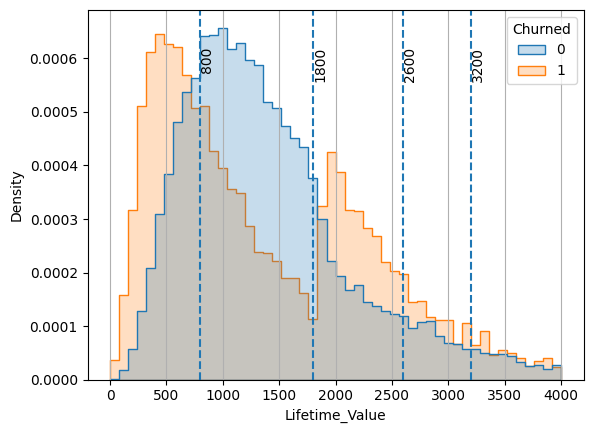

In [8]:
limits = [800, 1800, 2600, 3200]

ax = sns.histplot(
    train_df.query('Lifetime_Value < 4000'),
    x='Lifetime_Value',
    hue='Churned',
    bins=50,
    element='step',
    stat='density',
    common_norm=False
)

# Keep regular ticks every 500
ax.xaxis.set_major_locator(mticker.MultipleLocator(500))

# Add vertical lines at your limits
for t in limits:
    ax.axvline(t, linestyle='--')
    ax.text(t, ax.get_ylim()[1]*0.9, f'{t}', rotation=90, va='top')
    
ax.grid(axis='x')
plt.show()

C:\Users\Monika\AppData\Local\Temp\ipykernel_10160\962854464.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = train_df.groupby('lv_bin')['Churned'].mean()


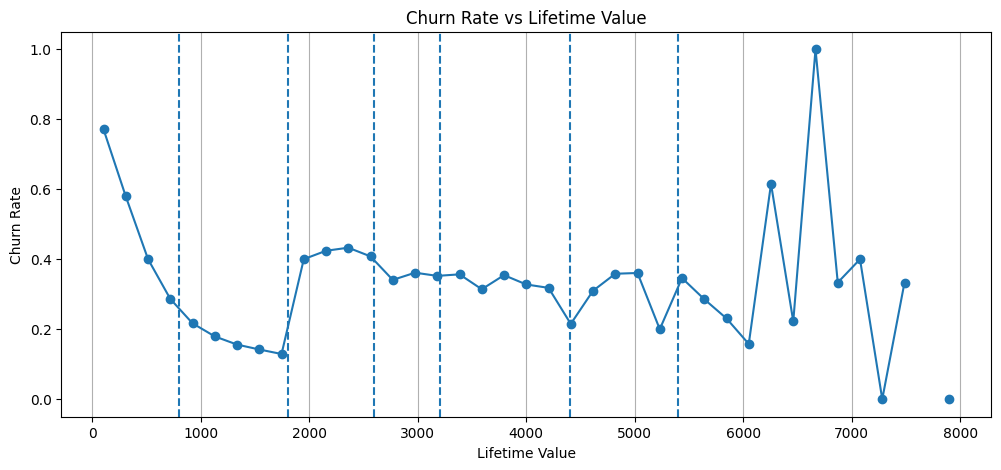

In [61]:
bins = np.linspace(0, 8000, 40)
train_df['lv_bin'] = pd.cut(train_df['Lifetime_Value'], bins=bins)

# churn rate per bin
churn_rate = train_df.groupby('lv_bin')['Churned'].mean()

# midpoints for plotting
x = [interval.mid for interval in churn_rate.index]

plt.figure(figsize=(12,5))
plt.plot(x, churn_rate, marker='o')

# your thresholds
for t in [800, 1800, 2600, 3200, 4400, 5400]:
    plt.axvline(t, linestyle='--')

plt.xlabel("Lifetime Value")
plt.ylabel("Churn Rate")
plt.title("Churn Rate vs Lifetime Value")
plt.grid(axis='x')
plt.show()

In [64]:
def churn_by_bins(bins):
    seg = pd.cut(train_df['Lifetime_Value'], bins=bins, right=False)
    return pd.crosstab(seg, train_df['Churned'], normalize='index')[1]

bin1_churn = churn_by_bins([0, 800, 1800, 2600, np.inf])
bin2_churn = churn_by_bins([0, 800, 1800, 2700, np.inf])
bin3_churn = churn_by_bins([0, 800, 1800, 3200, np.inf])
bin4_churn = churn_by_bins([0, 800, 1800, 2600, 4400, np.inf])
bin5_churn = churn_by_bins([0, 800, 1800, 3200, 4400, np.inf])


pd.concat([bin1_churn, bin2_churn, bin3_churn, bin4_churn, bin5_churn], axis=1, keys=['Bin1', 'Bin2', 'Bin3', 'Bin4', 'Bin5'])

,Bin1,Bin2,Bin3,Bin4,Bin5
Lifetime_Value,,,,,
"[0.0, 800.0)",0.410101,0.410101,0.410101,0.410101,0.410101
"[800.0, 1800.0)",0.174503,0.174503,0.174503,0.174503,0.174503
"[1800.0, 2600.0)",0.389236,NaN,NaN,0.389236,NaN
"[2600.0, inf)",0.345739,NaN,NaN,NaN,NaN
"[1800.0, 2700.0)",NaN,0.389003,NaN,NaN,NaN
"[2700.0, inf)",NaN,0.340633,NaN,NaN,NaN
"[1800.0, 3200.0)",NaN,NaN,0.382736,NaN,0.382736
"[3200.0, inf)",NaN,NaN,0.325836,NaN,NaN
"[2600.0, 4400.0)",NaN,NaN,NaN,0.349344,NaN


Based on quantile and distribution, following segments are considered:
| Segment | Range              | Represents                     |
|--------|--------------------|--------------------------------|
| Low    | 0 – 800            | Bottom 25%                    |
| Medium | 800 – 1800         | 25th to 75th percentile       |
| High   | 1800 – 2600        | 75th to 90th percentile       |
| IMP    | 2600 – 4400        | 90th to 99th percentile       |
| VIP    | 4400+              | Top 1%                        |

3200 stays in the middle of the cuttoff and `churn rate vs clv` plot shows ongoing trend in churn rate.

In [65]:
bins = [0, 800, 1800, 2600, 4400, np.inf]
labels = ['Low', 'Medium', 'High', 'IMP', 'VIP']

ltv_segments = pd.cut(
    train_df['Lifetime_Value'],
    bins=bins,
    labels=labels,
    right=False  # makes intervals like [800, 1800)
)

pd.crosstab(
    ltv_segments,
    train_df['Churned'],
    normalize='index'
)

Churned,0,1
Lifetime_Value,,
Low,0.589899,0.410101
Medium,0.825497,0.174503
High,0.610764,0.389236
IMP,0.650656,0.349344
VIP,0.688202,0.311798


## business rentention - naive method

In [8]:
top1_ltv_Xtest = Xtest.query('Lifetime_Value > 2600')
top1_ltv_ytest = ytest[top1_ltv_Xtest.index]

top1_ltv_ypred = xgb.predict(top1_ltv_Xtest)
recall_score(top1_ltv_ytest, top1_ltv_ypred)

0.8886756238003839

0.8886756238003839